### Reproducing Public Dataset Experiments (LANTERN)

This notebook reproduces the progressive drift evaluation on public datasets
(CICIoT2023 and Android Malware), as described in the paper.

It executes the full pipeline including:
- data preprocessing
- model training
- drift scoring
- evaluation

In [1]:
import sys
print(sys.version)

3.9.21 (main, Dec 11 2024, 16:24:11) 
[GCC 11.2.0]


### How to run the code:

In [2]:
!python3 ../comparison/stage.py --dataset ciciot2023

[INFO] Loading and splitting data...
[INFO] benign: train=4000, test=1000
[INFO] HTTP Flood: train=4000, test=1000
[INFO] OS Scan: train=4000, test=1000
[INFO] Command Injection: train=4000, test=1000
[INFO] BrowserHijacking: train=4000, test=1000
[INFO] SQL Injection: train=4000, test=1000
[INFO] XSS: train=3076, test=770
[INFO] Number of numeric features: 39
[INFO] Model: cae

[INFO] Baseline Stage (seen only)
[Device] Using CUDA for CAE training.
[CAE] Epoch 1/10 | Loss=1.133480
[CAE] Epoch 2/10 | Loss=0.673307
[CAE] Epoch 3/10 | Loss=0.490337
[CAE] Epoch 4/10 | Loss=0.370161
[CAE] Epoch 5/10 | Loss=0.290576
[CAE] Epoch 6/10 | Loss=0.245767
[CAE] Epoch 7/10 | Loss=0.215018
[CAE] Epoch 8/10 | Loss=0.192370
[CAE] Epoch 9/10 | Loss=0.174572
[CAE] Epoch 10/10 | Loss=0.160810
[CAE] Restoring best model (Loss=0.160810)

[INFO] Stage 1
[INFO] Seen classes: ['benign', 'HTTP Flood']
[INFO] Probe class: OS Scan
[INFO] Training model...
[Device] Using CUDA for CAE training.
[CAE] Epoch 1/10 | 

In [3]:
!python3 ../comparison/stage.py --dataset android

[INFO] Loading and splitting data...
[INFO] benign: total=5802, train=4000, test=1000
[INFO] dowgin: total=6675, train=4000, test=1000
[INFO] fakeapp: total=9215, train=4000, test=1000
[INFO] simplelocker: total=8401, train=4000, test=1000
[INFO] plankton: total=8699, train=4000, test=1000
[INFO] svpeng: total=12192, train=4000, test=1000
[INFO] youmi: total=6306, train=4000, test=1000
[INFO] Number of numeric features: 80
[INFO] Model: cae

[INFO] Baseline Stage (seen only)
[Device] Using CUDA for CAE training.
[CAE] Epoch 1/10 | Loss=1.223433
[CAE] Epoch 2/10 | Loss=0.925999
[CAE] Epoch 3/10 | Loss=0.759610
[CAE] Epoch 4/10 | Loss=0.670558
[CAE] Epoch 5/10 | Loss=0.629148
[CAE] Epoch 6/10 | Loss=0.600084
[CAE] Epoch 7/10 | Loss=0.577032
[CAE] Epoch 8/10 | Loss=0.561573
[CAE] Epoch 9/10 | Loss=0.548932
[CAE] Epoch 10/10 | Loss=0.540473
[CAE] Restoring best model (Loss=0.540473)

[INFO] Stage 1
[INFO] Seen classes: ['benign', 'dowgin']
[INFO] Probe class: fakeapp
[INFO] Training model.

### Analysis and Visualization

In [4]:
import pandas as pd
import numpy as np


def add_delta_columns(df: pd.DataFrame, methods=None) -> pd.DataFrame:
    """
    Add per-method delta columns:
    Delta = Unseen - Seen
    DeltaRatio currently mirrors Delta as in the original notebook logic.
    """
    if methods is None:
        methods = ["cade", "chen", "gidx", "pe", "lmt"]

    df = df.copy()

    for m in methods:
        benign_col = f"{m}_score_benign"
        seen_col = f"{m}_score_seen_mean"
        unseen_col = f"{m}_score_unseen"
        delta_col = f"{m}_delta"
        deltaratio_col = f"{m}_deltaratio"

        if seen_col in df.columns and unseen_col in df.columns:
            df[delta_col] = df[unseen_col] - df[seen_col]
            df[deltaratio_col] = df[delta_col]
        else:
            df[delta_col] = np.nan
            df[deltaratio_col] = np.nan

    return df


def make_stage_label(row: pd.Series) -> str:
    """
    Convert seen_classes into a readable stage label.
    Example:
    'Benign | HTTP Flood | OS Scan' -> 'S2 = Benign + Attack(1..2)'
    """
    classes = [x.strip() for x in str(row["seen_classes"]).split("|")]
    if len(classes) <= 1:
        return "Baseline"

    attacks = [c for c in classes if c != "Benign"]
    if len(attacks) == 0:
        return "Baseline"

    return f"S{len(attacks)} = Benign + Attack(1..{len(attacks)})"


def add_stage_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add stage_label column.
    """
    df = df.copy()
    df["stage_label"] = df.apply(make_stage_label, axis=1)
    return df


def build_table_long(df: pd.DataFrame, methods=None, round_digits=2) -> pd.DataFrame:
    """
    Transform the wide experiment CSV into the long-format summary table.
    """
    if methods is None:
        methods = ["cade", "chen", "gidx", "pe", "lmt"]

    rows = []

    for _, r in df.iterrows():
        for m in methods:
            rows.append({
                "Stage": r["stage_label"],
                "Stage_ID": r["stage_id"],
                "Probe": r["probe_class"],
                "Drift Method": m.upper(),
                "Acc": r["accuracy"],
                "F1": r["f1_macro"],
                "Benign": r.get(f"{m}_score_benign", np.nan),
                "Seen": r.get(f"{m}_score_seen_mean", np.nan),
                "Unseen": r.get(f"{m}_score_unseen", np.nan),
                "Delta": r.get(f"{m}_delta", np.nan),
            })

    table_long = pd.DataFrame(rows)

    num_cols = ["Acc", "F1", "Benign", "Seen", "Unseen", "Delta"]
    for col in num_cols:
        if col in table_long.columns:
            table_long[col] = table_long[col].round(round_digits)

    return table_long


def load_progressive_results(csv_path: str, methods=None, round_digits=2):
    """
    Full pipeline:
    1. load csv
    2. add delta columns
    3. add stage labels
    4. build long table

    Returns:
        df_raw, table_long
    """
    if methods is None:
        methods = ["cade", "chen", "gidx", "pe", "lmt"]

    df = pd.read_csv(csv_path)
    df = add_delta_columns(df, methods=methods)
    df = add_stage_labels(df)
    table_long = build_table_long(df, methods=methods, round_digits=round_digits)

    return df, table_long

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_conditional_subplots(
    table_long: pd.DataFrame,
    save_path="ciciot23.pdf",
    method_order=None,
    figsize_per_plot=(5, 6),
    font_main=32,
    font_extra=30,
    show=True,
):
    """
    Plot 1 x N subplot of conditional drift scores (Benign, Seen, Unseen).

    Parameters
    ----------
    table_long : pd.DataFrame
        Must contain columns:
        Stage, Stage_ID, Probe, Drift Method, Benign, Seen, Unseen

    save_path : str
        Output figure path

    method_order : list or None
        Order of methods to display

    figsize_per_plot : tuple
        Size per subplot (width, height)

    font_main : int
        Main font size

    show : bool
        Whether to display the plot
    """

    # ---------------------------------------------------------
    # Style
    # ---------------------------------------------------------
    COLORS = {
        "dark_blue": "#34669A",
        "orange": "#E0795F",
        "red": "#B00A0B",
    }

    plt.rcParams["font.size"] = font_main
    plt.rcParams["axes.labelsize"] = font_main
    plt.rcParams["xtick.labelsize"] = font_main
    plt.rcParams["ytick.labelsize"] = font_main
    plt.rcParams["legend.fontsize"] = font_main

    # ---------------------------------------------------------
    # Clean data
    # ---------------------------------------------------------
    dfp = table_long.copy()

    dfp = dfp[dfp["Probe"].astype(str) != "None"].copy()
    dfp["Drift Method"] = dfp["Drift Method"].astype(str).str.upper()
    dfp = dfp.dropna(subset=["Benign", "Seen", "Unseen"])

    # method order
    if method_order is None:
        method_order = ["CADE", "CHEN", "GIDX", "PE", "LMT"]

    method_order = [m for m in method_order if m in dfp["Drift Method"].unique()]

    # stage order
    stage_order = (
        dfp[["Stage_ID", "Stage"]]
        .drop_duplicates()
        .sort_values("Stage_ID")
    )

    stage_ids = stage_order["Stage_ID"].tolist()

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    n_methods = len(method_order)
    fig_w = figsize_per_plot[0] * n_methods
    fig_h = figsize_per_plot[1]

    fig, axes = plt.subplots(1, n_methods, figsize=(fig_w, fig_h), sharex=True)

    if n_methods == 1:
        axes = [axes]

    for ax, method in zip(axes, method_order):
        sub = dfp[dfp["Drift Method"] == method].copy()
        sub = sub.sort_values("Stage_ID")

        sub = (
            pd.DataFrame({"Stage_ID": stage_ids})
            .merge(sub, on="Stage_ID", how="left")
        )

        x = np.arange(len(stage_ids))

        ax.plot(
            x, sub["Benign"].values,
            marker="o", linewidth=3, markersize=10,
            color=COLORS["dark_blue"], label="Benign"
        )
        ax.plot(
            x, sub["Seen"].values,
            marker="s", linewidth=3, markersize=10,
            color=COLORS["orange"], label="Seen"
        )
        ax.plot(
            x, sub["Unseen"].values,
            marker="^", linewidth=3, markersize=12,
            color=COLORS["red"], label="Unseen"
        )

        ax.set_title(method, fontsize=font_main)
        ax.set_xticks(x)
        ax.set_xticklabels([f"S{i+1}" for i in range(len(stage_ids))])
        ax.grid(alpha=0.25)

        if ax is axes[0]:
            ax.set_ylabel("Drift Score", fontsize=font_main)

    # shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

    fig.supxlabel("Stage", fontsize=font_main, y=0.2)

    plt.tight_layout(rect=[0, 0.05, 1, 0.9])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

    return stage_order.reset_index(drop=True)

In [7]:
## Get the table
csv_path = "../data/public_datasets/resiot/public_progressive_cae.csv"
methods = ["cade", "chen", "gidx", "pe", "lmt"]

df, table_long = load_progressive_results(
    csv_path=csv_path,
    methods=methods,
    round_digits=2,
)

print(df[["stage_id", "seen_classes", "stage_label", "probe_class"]].head())
table_long.head(20)

   stage_id                                       seen_classes  \
0         0                                benign | HTTP Flood   
1         1                                benign | HTTP Flood   
2         2                      benign | HTTP Flood | OS Scan   
3         3  benign | HTTP Flood | OS Scan | Command Injection   
4         4  benign | HTTP Flood | OS Scan | Command Inject...   

                  stage_label        probe_class  
0  S2 = Benign + Attack(1..2)                NaN  
1  S2 = Benign + Attack(1..2)            OS Scan  
2  S3 = Benign + Attack(1..3)  Command Injection  
3  S4 = Benign + Attack(1..4)   BrowserHijacking  
4  S5 = Benign + Attack(1..5)      SQL Injection  


,Stage,Stage_ID,Probe,Drift Method,Acc,F1,Benign,Seen,Unseen,Delta
0,S2 = Benign + Attack(1..2),0,NaN,CADE,1.00,1.00,1.40,1.14,NaN,NaN
1,S2 = Benign + Attack(1..2),0,NaN,CHEN,1.00,1.00,1.27,1.65,NaN,NaN
2,S2 = Benign + Attack(1..2),0,NaN,GIDX,1.00,1.00,0.25,0.25,NaN,NaN
3,S2 = Benign + Attack(1..2),0,NaN,PE,1.00,1.00,0.01,0.01,NaN,NaN
4,S2 = Benign + Attack(1..2),0,NaN,LMT,1.00,1.00,23.09,20.94,NaN,NaN
5,S2 = Benign + Attack(1..2),1,OS Scan,CADE,0.80,0.60,1.34,1.13,3.39,2.25
6,S2 = Benign + Attack(1..2),1,OS Scan,CHEN,0.80,0.60,1.31,1.66,1.00,-0.66
7,S2 = Benign + Attack(1..2),1,OS Scan,GIDX,0.80,0.60,0.25,0.25,0.27,0.02
8,S2 = Benign + Attack(1..2),1,OS Scan,PE,0.80,0.60,0.01,0.01,0.14,0.13
9,S2 = Benign + Attack(1..2),1,OS Scan,LMT,0.80,0.60,22.23,21.05,114.48,93.43


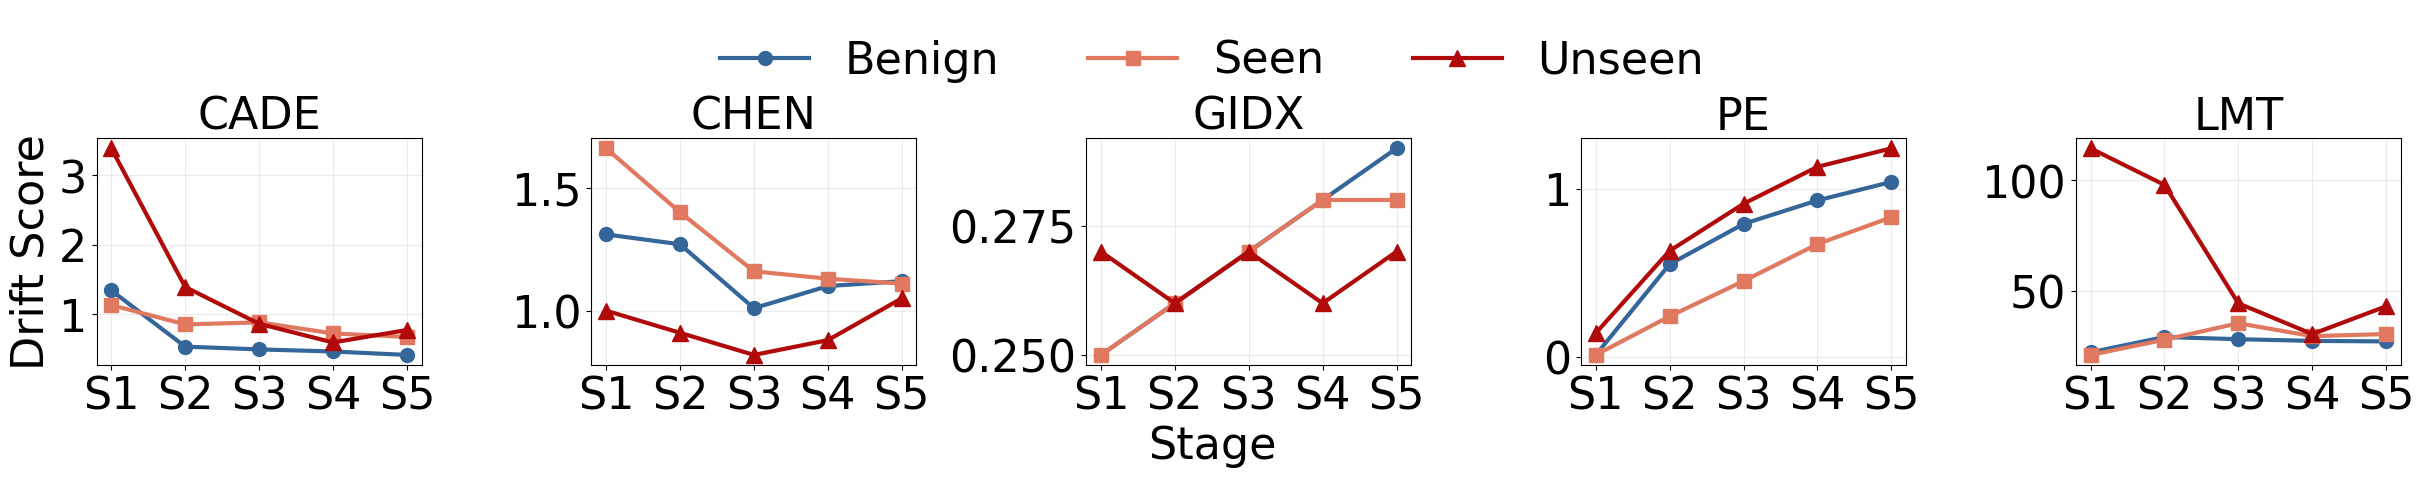

   Stage_ID                       Stage
0         1  S2 = Benign + Attack(1..2)
1         2  S3 = Benign + Attack(1..3)
2         3  S4 = Benign + Attack(1..4)
3         4  S5 = Benign + Attack(1..5)
4         5  S6 = Benign + Attack(1..6)


In [9]:
stage_map = plot_conditional_subplots(
    table_long,
    save_path="../data/figs/ciciot23.pdf",
)
print(stage_map)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _prepare_plot_table(table_long: pd.DataFrame, method_order=None):
    dfp = table_long.copy()

    dfp = dfp[dfp["Probe"].astype(str) != "None"].copy()
    dfp["Drift Method"] = dfp["Drift Method"].astype(str).str.upper()
    dfp = dfp.dropna(subset=["Benign", "Seen", "Unseen"])

    if method_order is None:
        method_order = ["CADE", "CHEN", "ENIDRIFT", "PE", "LMT"]

    method_order = [m for m in method_order if m in dfp["Drift Method"].unique()]

    stage_order = (
        dfp[["Stage_ID", "Stage"]]
        .drop_duplicates()
        .sort_values("Stage_ID")
        .reset_index(drop=True)
    )

    stage_ids = stage_order["Stage_ID"].tolist()

    return dfp, method_order, stage_order, stage_ids


def plot_conditional_subplots_2xN(
    table_long_top: pd.DataFrame,
    table_long_bottom: pd.DataFrame,
    top_label="(a) CICIoT2023",
    bottom_label="(b) AndMal2017",
    save_path="conditional_2xN.pdf",
    method_order=None,
    figsize_per_plot=(5, 6),
    font_main=32,
    font_extra=30,
    show=True,
):
    """
    Plot 2 x N subplot of conditional drift scores (Benign, Seen, Unseen),
    with shared x axis, shared legend, and titles only on the top row.
    """

    # ---------------------------------------------------------
    # Style
    # ---------------------------------------------------------
    COLORS = {
        "dark_blue": "#34669A",
        "orange": "#E0795F",
        "red": "#B00A0B",
    }

    plt.rcParams["font.size"] = font_main
    plt.rcParams["axes.labelsize"] = font_main
    plt.rcParams["xtick.labelsize"] = font_main
    plt.rcParams["ytick.labelsize"] = font_main
    plt.rcParams["legend.fontsize"] = font_main

    # ---------------------------------------------------------
    # Clean data
    # ---------------------------------------------------------
    dfp_top, methods_top, stage_order_top, stage_ids_top = _prepare_plot_table(
        table_long_top, method_order=method_order
    )
    dfp_bottom, methods_bottom, stage_order_bottom, stage_ids_bottom = _prepare_plot_table(
        table_long_bottom, method_order=method_order
    )

    if method_order is None:
        method_order = ["CADE", "CHEN", "ENIDRIFT", "PE", "LMT"]

    method_order = [
        m for m in method_order
        if m in methods_top and m in methods_bottom
    ]

    if stage_ids_top != stage_ids_bottom:
        raise ValueError("Top and bottom tables do not share the same Stage_ID order.")

    stage_ids = stage_ids_top
    x = np.arange(len(stage_ids))
    xticklabels = [f"S{i+1}" for i in range(len(stage_ids))]

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    n_methods = len(method_order)
    fig_w = figsize_per_plot[0] * n_methods
    fig_h = figsize_per_plot[1] * 2

    fig, axes = plt.subplots(
        2, n_methods,
        figsize=(fig_w, fig_h),
        sharex=True,
    )

    if n_methods == 1:
        axes = np.array(axes).reshape(2, 1)

    all_tables = [dfp_top, dfp_bottom]

    for row_idx, dfp in enumerate(all_tables):
        for col_idx, method in enumerate(method_order):
            ax = axes[row_idx, col_idx]

            sub = dfp[dfp["Drift Method"] == method].copy()
            sub = sub.sort_values("Stage_ID")

            sub = (
                pd.DataFrame({"Stage_ID": stage_ids})
                .merge(sub, on="Stage_ID", how="left")
            )

            ax.plot(
                x, sub["Benign"].values,
                marker="o", linewidth=3, markersize=10,
                color=COLORS["dark_blue"], label="Benign"
            )
            ax.plot(
                x, sub["Seen"].values,
                marker="s", linewidth=3, markersize=10,
                color=COLORS["orange"], label="Seen"
            )
            ax.plot(
                x, sub["Unseen"].values,
                marker="^", linewidth=3, markersize=12,
                color=COLORS["red"], label="Unseen"
            )

            if row_idx == 0:
                ax.set_title(method, fontsize=font_main)

            ax.set_xticks(x)
            ax.set_xticklabels(xticklabels)
            ax.grid(alpha=0.8)

            #if col_idx == 0:
            #    ax.set_ylabel("Drift Score", fontsize=font_main)
            fig.supylabel("Drift Score", fontsize=font_main, x=0.035)

    # shared legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

    # shared x label
    fig.supxlabel("Stage", fontsize=font_main, y=0.15)

    # row labels
    #fig.text(0.5, 0.49, top_label, ha="center", va="center", fontsize=font_extra)
    #fig.text(0.5, 0.01, bottom_label, ha="center", va="bottom", fontsize=font_extra)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

    return stage_order_top

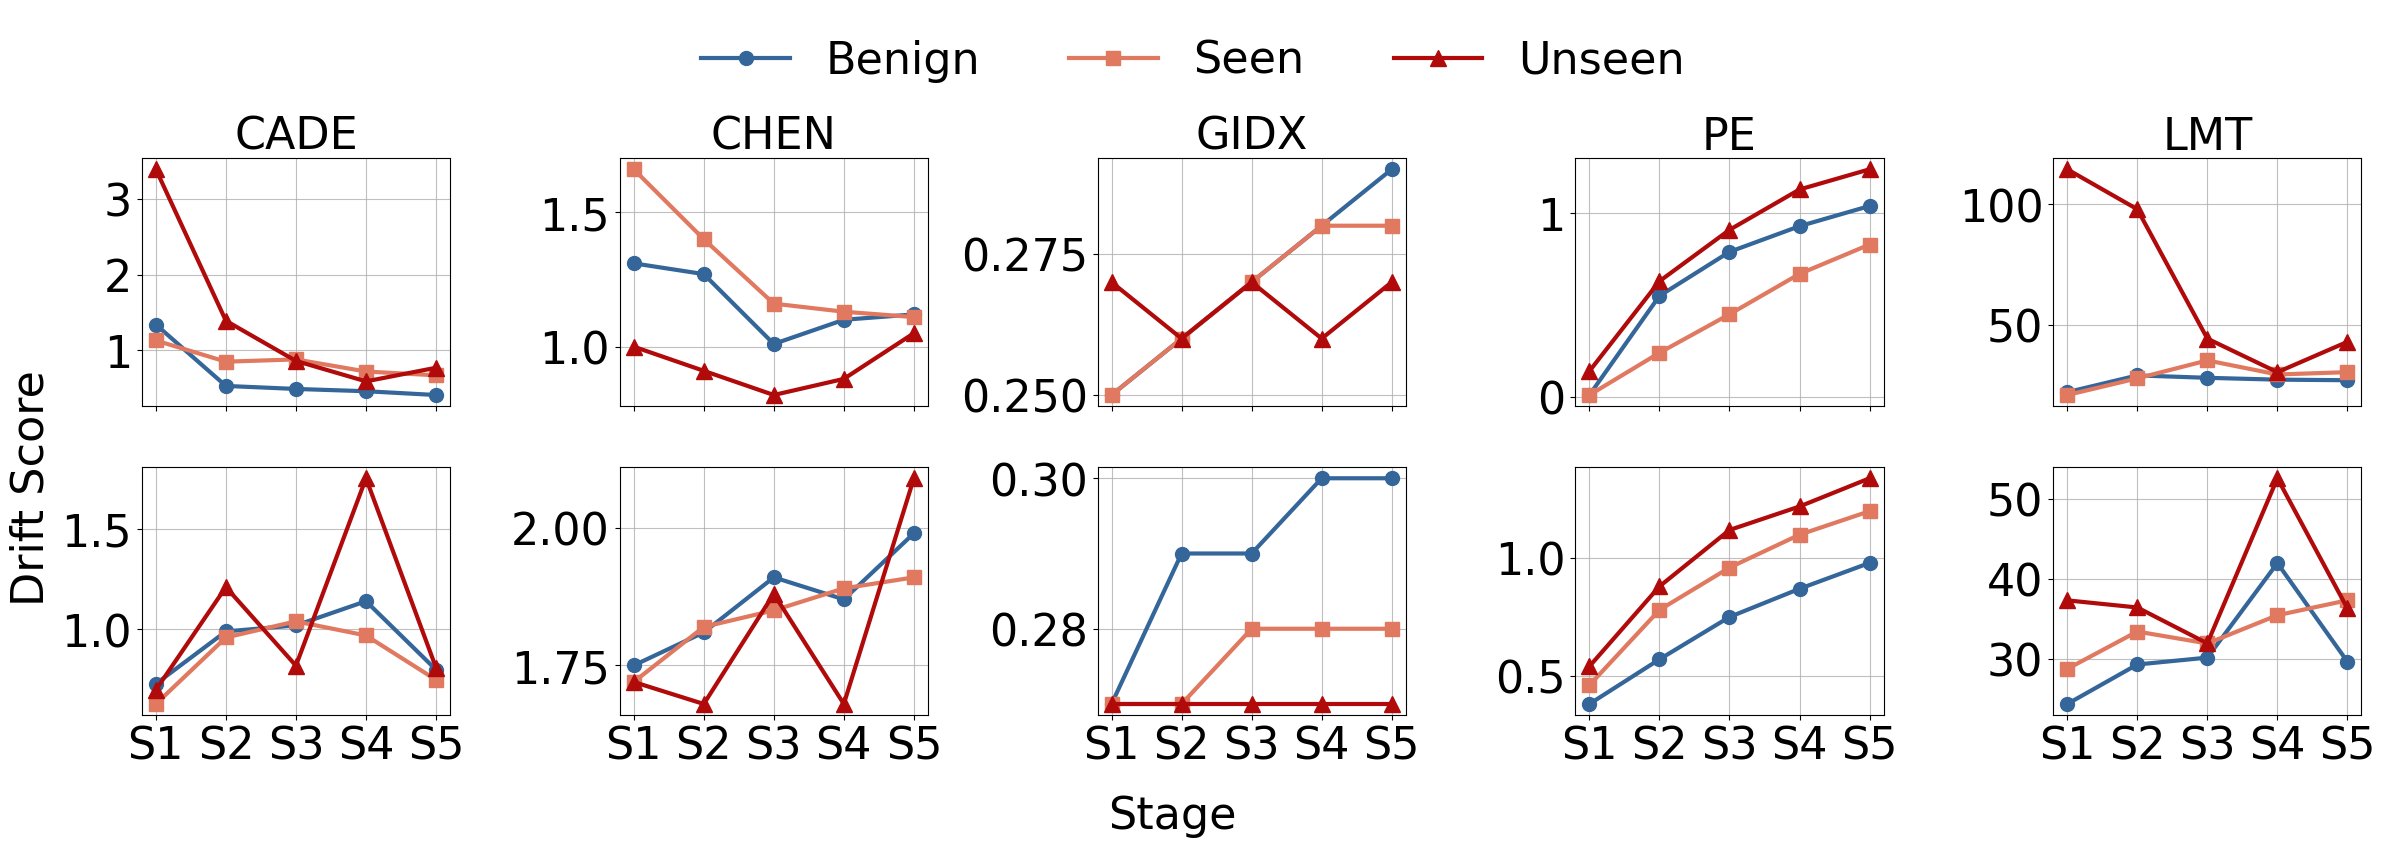

   Stage_ID                       Stage
0         1  S2 = Benign + Attack(1..2)
1         2  S3 = Benign + Attack(1..3)
2         3  S4 = Benign + Attack(1..4)
3         4  S5 = Benign + Attack(1..5)
4         5  S6 = Benign + Attack(1..6)


In [13]:
csv_path_top = "../data/public_datasets/resiot/public_progressive_cae.csv"
csv_path_bottom = "../data/public_datasets/res_android_mal/public_progressive_cae.csv"
methods = ["cade", "chen", "gidx", "pe", "lmt"]

df_top, table_long_top = load_progressive_results(
    csv_path=csv_path_top,
    methods=methods,
    round_digits=2,
)

df_bottom, table_long_bottom = load_progressive_results(
    csv_path=csv_path_bottom,
    methods=methods,
    round_digits=2,
)

stage_map = plot_conditional_subplots_2xN(
    table_long_top,
    table_long_bottom,
    top_label="(a) CICIoT2023",
    bottom_label="(b) AndMal2017",
    save_path="../data/figs/conditional_2xN.pdf",
    method_order=["CADE", "CHEN", "GIDX", "PE", "LMT"],
    figsize_per_plot=(5, 5),
    font_main=32,
    font_extra=30,
    show=True,
)

print(stage_map)